https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

# preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor import architecture
from msi.utils import preprocessing, plotting
from msfm.utils import prior, parameters, files, logger, cross_statistics

24-01-31 05:49:53   imports.py INF   Setting up healpy to run on 256 CPUs 


# load the summary statistics

### v6

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/DESY3/v6/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v6"

pca_components = 20

# lensing only
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
with_lensing = True
with_clustering = False
with_cross_z = True
with_cross_probe = False

# # clustering only
# params = ["Om", "s8", "w0", "bg", "n_bg"]
# with_lensing = False
# with_clustering = True
# with_cross_z = True
# with_cross_probe = False

# # combined probes
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]
# with_lensing = True
# with_clustering = True
# with_cross_z = True
# with_cross_probe = True

label = f"lensing={with_lensing},clustering={with_clustering},cross_z={with_cross_z},cross_probe={with_cross_probe},pca={pca_components}"

bin_indices, bin_names = cross_statistics.get_cross_bin_indices(
        with_lensing=with_lensing,
        with_clustering=with_clustering,
        with_cross_z=with_cross_z,
        with_cross_probe=with_cross_probe,
)

#### power spectra

In [4]:
# summary = "cls"

# fidu_summs, grid_summs, grid_cosmos, file_dict = preprocessing.get_reshaped_human_summaries(
#     os.path.join(base_dir, summary), 
#     summary, 
#     # file
#     file_label=None,
#     # configuration
#     conf=conf, 
#     params=params,
#     concat_example_dim=True,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
#     # additional preprocessing
#     apply_log=False,
#     pca_components=pca_components,
# )

# # TODO fix this in the cls file generation
# grid_cosmos = grid_cosmos[:,0,:]

# out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != summary) else out_dir

#### peaks

24-01-31 05:49:55 input_output INF   Array shapes: 
24-01-31 05:49:55 input_output INF   fiducial/peaks     = (2400, 2, 15, 36) 
24-01-31 05:49:55 input_output INF   fiducial/i_example = (2400,) 
24-01-31 05:49:55 input_output INF   fiducial/i_noise   = (2400,) 
24-01-31 05:49:55 input_output INF   grid/peaks         = (2500, 48, 2, 15, 36) 
24-01-31 05:49:55 input_output INF   grid/cosmo         = (2500, 10) 
24-01-31 05:49:55 input_output INF   grid/i_example     = (2500, 48) 
24-01-31 05:49:55 input_output INF   grid/i_noise       = (2500, 48) 
24-01-31 05:49:55 input_output INF   grid/i_sobol       = (2500,) 
24-01-31 05:49:55 preprocessin INF   Using the bin indices [0, 1, 2, 3, 8, 9, 10, 15, 16, 21] 
24-01-31 05:49:55 preprocessin INF   With names ['bin_0x0' 'bin_0x1' 'bin_0x2' 'bin_0x3' 'bin_1x1' 'bin_1x2' 'bin_1x3'
 'bin_2x2' 'bin_2x3' 'bin_3x3'] 


24-01-31 05:49:55 preprocessin INF   Shapes after selection 
24-01-31 05:49:55 preprocessin INF   fidu_peaks = (2400, 2, 15, 10) 


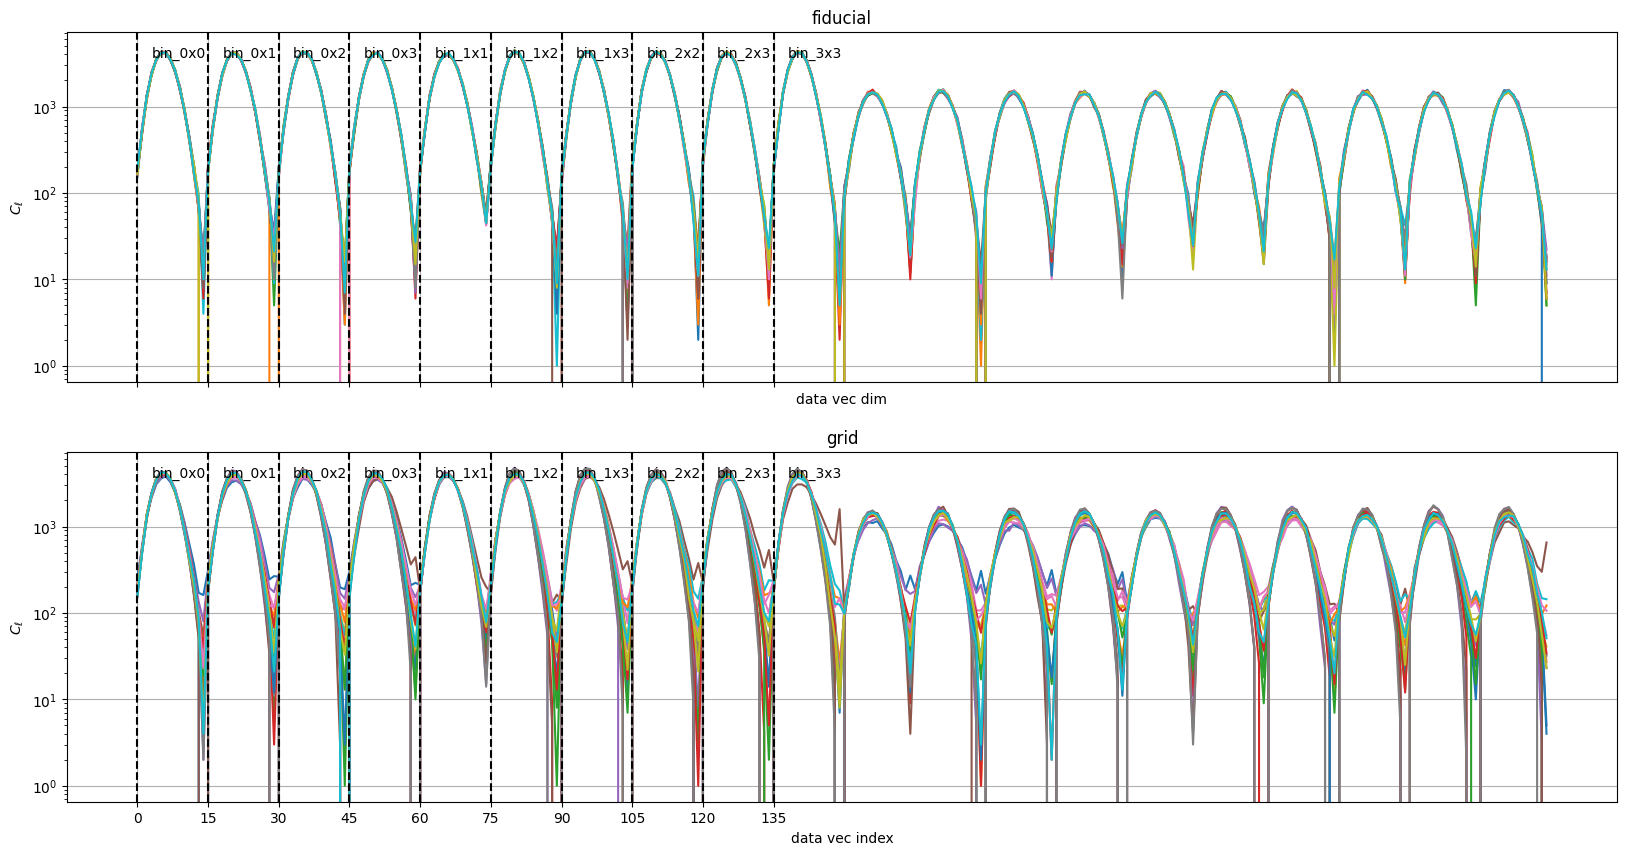

In [5]:
summary = "peaks"

fidu_summs, grid_summs, grid_cosmos, file_dict = preprocessing.get_reshaped_human_summaries(
    os.path.join(base_dir, summary), 
    summary, 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=with_cross_z,
    with_cross_probe=with_cross_probe,
    # additional preprocessing
    apply_log=False,
    pca_components=pca_components,
)

out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != "peaks") else out_dir

### general

In [6]:
os.makedirs(out_dir, exist_ok=True)

# likelihood Flow $p(x|\theta)$

In [7]:
# input dimensions
x_dim = grid_summs.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=64,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 10,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
)

24-01-31 05:49:58 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v6/peaks/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=20/likelihood_flow 
24-01-31 05:49:58 likelihood_f INF   Initialized the normalizing flow 
24-01-31 05:49:59 likelihood_f INF   Running on device cuda with default float torch.float32 
24-01-31 05:49:59 likelihood_f INF   Initializing fresh weights 


### training

24-01-31 05:50:00 likelihood_f INF   Using a cosine annealing scheduler 
24-01-31 05:50:00 likelihood_f INF   Using early stopping with patience 10 and min delta 0.0 
 31%|████████▋                   |   | 31/100 [03:44<08:03,  7.01s/it]        lr: 7.83E-04, train: 15.57, vali: 15.79: 24-01-31 05:53:51   pytorch.py INF   <All keys matched successfully> 
24-01-31 05:53:51   pytorch.py INF   Restored the weights from the best epoch (vali_loss = 15.65) 
24-01-31 05:53:51 likelihood_f INF   Stopping early after 31 epochs 
 31%|████████▋                   |   | 31/100 [03:51<08:35,  7.47s/it]        lr: 7.83E-04, train: 15.57, vali: 15.79: 
24-01-31 05:53:51 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/peaks/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=20/likelihood_flow/likelihood_flow.pt 


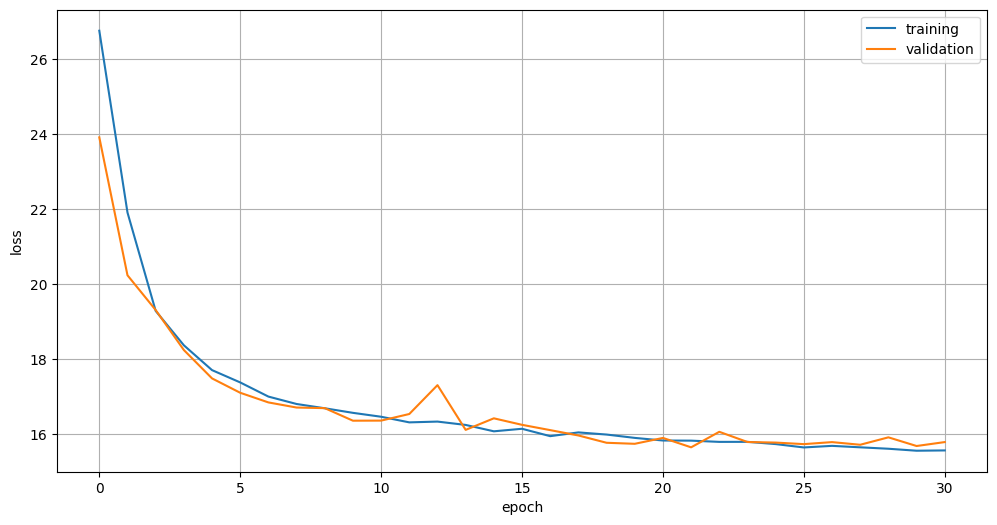

In [8]:
flow.fit(
    x=grid_summs,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=1000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=100.0,
    # scheduler
    scheduler_type="cosine",
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

### convergence tests

In [9]:
# _, raw_grid_summs, raw_grid_cosmos, _ = preprocessing.get_reshaped_human_summaries(
#     os.path.join(base_dir, summary), 
#     summary, 
#     # file
#     file_label=None,
#     # configuration
#     conf=conf, 
#     params=params,
#     concat_example_dim=False,
#     # selection
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     with_cross_z=with_cross_z,
#     with_cross_probe=with_cross_probe,
#     # additional preprocessing
#     apply_log=False,
#     pca_components=pca_components,
#     do_plot=False,
# )

# # TODO fix this in the cls file generation
# # raw_grid_cosmos = raw_grid_cosmos[:,0,:]

# _ = flow.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=raw_grid_summs, 
#     grid_cosmos=raw_grid_cosmos,
#     n_samples=100,
#     do_hist=False,
#     do_dlss=False,
#     do_eecp=True,
#     do_tarp=True,
#     tarp_kwargs={"reference_dist": "uniform", "reference_scale": 1, "reference_dependence": False},
# )

### observation

In [10]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_summs[i_obs]

Using the example index 0


### MCMC

In [11]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-01-31 05:53:52      mcmc.py INF   Initial values in prior: True 
24-01-31 05:53:52      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-31 05:53:59      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:29<00:00, 17.07it/s]

24-01-31 05:54:28      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/peaks/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=20/likelihood_flow/chain.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-01-31 05:54:31  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/peaks/lensing=True,clustering=False,cross_z=True,cross_probe=False,pca=20/likelihood_flow/contours.png 


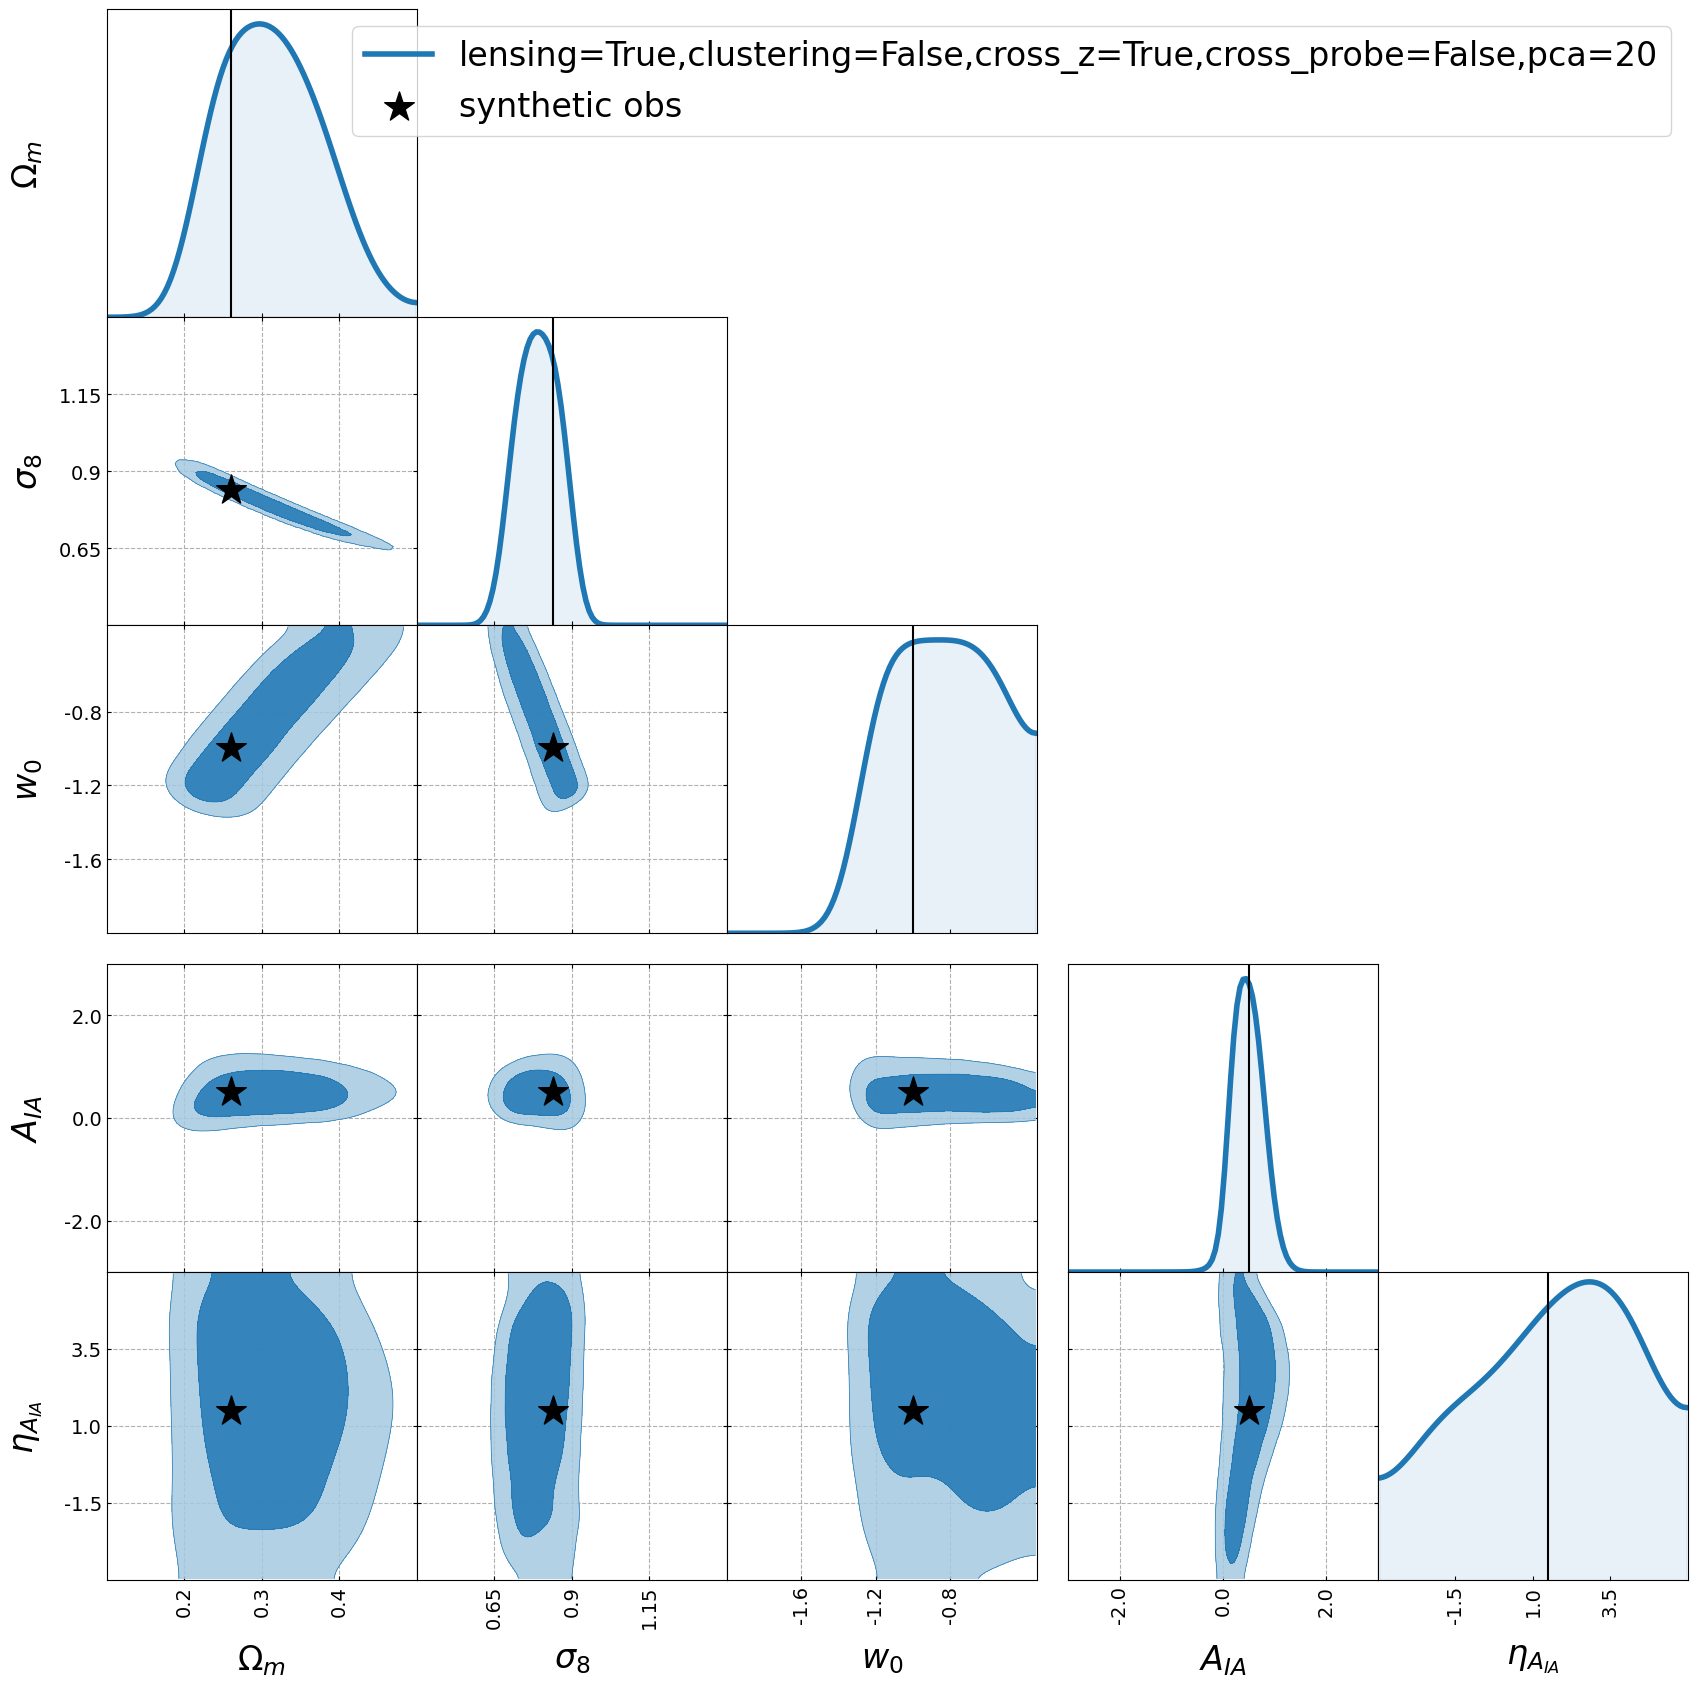

In [12]:
flow.plot_contours(
    posterior_samples,
)